In [1]:
import os
import glob
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import tqdm

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


In [2]:
# paths
SYMBOL_DIR    = "data/OHLC"
DELIVERY_DIR  = "data/bhav_data/weekly"
OUTPUT_CSV    = "backtest_results.csv"

# strategy params
MIN_WEEKS     = 100   # need ~100 weeks before EMA100 means anything
RSI_MIN       = 40
MIN_DELIV_PCT = 35
ENTRY_OFFSET  = 1.0    # entry = signal week high + 1
TAKE_PROFIT_PCT = 5.0
MAX_SL_PCT    = 5.0    # skip trade if SL is wider than this, keeps PL >= 1


In [3]:
def load_delivery_lookup(delivery_dir):
    # filename is DDMMYYYY.csv, each file has SYMBOL + AVG_DELIV_PER for that week
    lookup = {}
    for path in glob.glob(os.path.join(delivery_dir, "*.csv")):
        fname = os.path.splitext(os.path.basename(path))[0]
        try:
            file_date = dt.datetime.strptime(fname, "%d%m%Y").date()
        except ValueError:
            continue
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"could not read {path}: {e}")
            continue
        df.columns = [c.strip().upper() for c in df.columns]
        if "SYMBOL" not in df.columns or "AVG_DELIV_PER" not in df.columns:
            print(f"{path} missing SYMBOL/AVG_DELIV_PER, skipping")
            continue
        lookup[file_date] = dict(zip(df["SYMBOL"].astype(str).str.strip(), df["AVG_DELIV_PER"]))
    return lookup


def get_delivery_pct(delivery_lookup, week_date, symbol):
    day_map = delivery_lookup.get(week_date)
    if day_map is None:
        return None
    return day_map.get(symbol)


In [4]:
def clean_symbol(raw_symbol, fallback):
    # "NSE:3MINDIA" -> "3MINDIA"
    if isinstance(raw_symbol, str) and ":" in raw_symbol:
        return raw_symbol.split(":")[-1].strip()
    if isinstance(raw_symbol, str) and raw_symbol.strip():
        return raw_symbol.strip()
    return fallback


def simulate_trade(df, signal_idx, entry_price, stoploss, take_profit=None):
    n = len(df)
    trigger_idx = None
    for j in range(signal_idx + 1, n):
        if df["high"].iloc[j] >= entry_price:
            trigger_idx = j
            break

    if trigger_idx is None:
        return {
            "status": "NOT_TRIGGERED",
            "trigger_date": None,
            "exit_date": None,
            "exit_price": None,
            "return_pct": None,
        }

    exit_idx = None
    exit_price = None
    exit_status = None
    for j in range(trigger_idx, n):
        hit_sl = df["low"].iloc[j] <= stoploss
        hit_tp = take_profit is not None and df["high"].iloc[j] >= take_profit
        if hit_sl and hit_tp:
            # both hit same week cant tell which came first assume SL
            exit_idx, exit_price, exit_status = j, stoploss, "STOPPED_OUT"
            break
        if hit_sl:
            exit_idx, exit_price, exit_status = j, stoploss, "STOPPED_OUT"
            break
        if hit_tp:
            exit_idx, exit_price, exit_status = j, take_profit, "TARGET_HIT"
            break

    if exit_idx is None:
        last_close = df["close"].iloc[-1]
        return {
            "status": "OPEN",
            "trigger_date": df["datetime"].iloc[trigger_idx],
            "exit_date": None,
            "exit_price": last_close,
            "return_pct": round((last_close - entry_price) / entry_price * 100, 2),
        }

    return {
        "status": exit_status,
        "trigger_date": df["datetime"].iloc[trigger_idx],
        "exit_date": df["datetime"].iloc[exit_idx],
        "exit_price": exit_price,
        "return_pct": round((exit_price - entry_price) / entry_price * 100, 2),
    }


In [5]:
def scan_symbol(path, delivery_lookup):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values("datetime").reset_index(drop=True)

    fallback_symbol = os.path.splitext(os.path.basename(path))[0]
    symbol = clean_symbol(df["symbol"].iloc[0] if "symbol" in df.columns else None, fallback_symbol)

    required = ["high", "low", "close", "RSI_10", "RS", "EMA_20", "EMA_50", "EMA_100"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        print(f"{path} missing columns {missing}, skipping")
        return []

    signals = []
    n = len(df)
    if n <= MIN_WEEKS:
        return []

    for i in range(MIN_WEEKS, n):
        row = df.iloc[i]
        prev = df.iloc[i - 1]

        if pd.isna(row[required]).any() or pd.isna(prev[["high", "RS", "close", "EMA_20"]]).any():
            continue

        cond_breakout = row["close"] > prev["high"]
        cond_rsi = row["RSI_10"] >= RSI_MIN
        cond_rs_cross = (prev["RS"] < 0) and (row["RS"] >= 0)
        cond_ema_stack = (row["EMA_20"] > row["EMA_50"]) and (row["EMA_50"] > row["EMA_100"])
        cond_above_ema20 = (prev["close"] <= prev["EMA_20"]) and (row["close"] > row["EMA_20"])  # cross above not just above

        if not (cond_breakout and cond_rsi and cond_rs_cross and cond_ema_stack and cond_above_ema20):
            continue

        week_date = row["datetime"].date()
        deliv_pct = get_delivery_pct(delivery_lookup, week_date, symbol)
        if deliv_pct is None:
            continue
        if deliv_pct < MIN_DELIV_PCT:
            continue

        entry_price = row["high"] + ENTRY_OFFSET
        stoploss = row["low"]

        risk_pct = (entry_price - stoploss) / entry_price * 100
        if risk_pct > MAX_SL_PCT:
            continue

        take_profit = entry_price * (1 + TAKE_PROFIT_PCT / 100)

        trade = simulate_trade(df, i, entry_price, stoploss, take_profit)

        signals.append({
            "symbol": symbol,
            "signal_date": row["datetime"].date(),
            "signal_close": row["close"],
            "signal_high": row["high"],
            "signal_low": row["low"],
            "RSI_10": row["RSI_10"],
            "RS": row["RS"],
            "prev_RS": prev["RS"],
            "EMA_20": row["EMA_20"],
            "EMA_50": row["EMA_50"],
            "EMA_100": row["EMA_100"],
            "avg_deliv_pct": deliv_pct,
            "entry_price": round(entry_price, 2),
            "stoploss": round(stoploss, 2),
            "take_profit": round(take_profit, 2),
            "risk_pct": round(risk_pct, 2),
            **trade,
        })

    return signals


In [6]:
delivery_lookup = load_delivery_lookup(DELIVERY_DIR)

symbol_files = sorted(glob.glob(os.path.join(SYMBOL_DIR, "*.csv")))

all_signals = []
for path in tqdm.tqdm(symbol_files):
    all_signals.extend(scan_symbol(path, delivery_lookup))

result_df = pd.DataFrame(all_signals)
if not result_df.empty:
    result_df = result_df.sort_values("signal_date").reset_index(drop=True)

result_df


 70%|███████   | 301/430 [00:52<00:28,  4.53it/s]

data/OHLC\NIFTY.csv missing columns ['RSI_10', 'RS', 'EMA_20', 'EMA_50', 'EMA_100'], skipping


100%|██████████| 430/430 [01:18<00:00,  5.46it/s]


,symbol,signal_date,signal_close,signal_high,signal_low,RSI_10,RS,prev_RS,EMA_20,EMA_50,EMA_100,avg_deliv_pct,entry_price,stoploss,take_profit,risk_pct,status,trigger_date,exit_date,exit_price,return_pct
0,CIPLA,2022-07-11,966.05,968.65,927.05,52.52,0.01,-0.01,955.37,936.64,885.14,36.833333,969.65,927.05,1018.13,4.39,TARGET_HIT,2022-07-18 09:15:00,2022-08-01 09:15:00,1018.1325,5.00
1,CRISIL,2022-09-19,3286.05,3300.00,3150.10,52.18,0.02,-0.01,3247.94,3082.12,2755.31,51.103333,3301.00,3150.10,3466.05,4.57,STOPPED_OUT,2023-02-27 09:15:00,2023-02-27 09:15:00,3150.1000,-4.57
2,NESTLEIND,2022-09-26,957.24,959.75,919.88,56.23,0.01,-0.03,934.34,920.45,902.29,53.216667,960.75,919.88,1008.79,4.25,TARGET_HIT,2022-10-03 09:15:00,2022-10-17 09:15:00,1008.7875,5.00
3,SYNGENE,2023-01-02,596.10,603.25,576.00,54.08,0.03,-0.02,587.50,583.57,568.27,42.823333,604.25,576.00,634.46,4.68,STOPPED_OUT,2023-01-09 09:15:00,2023-01-23 09:15:00,576.0000,-4.68
4,CERA,2023-01-02,5295.95,5381.00,5175.75,52.80,0.03,-0.04,5216.45,4932.87,4513.82,45.535000,5382.00,5175.75,5651.10,3.83,TARGET_HIT,2023-01-09 09:15:00,2023-01-30 09:15:00,5651.1000,5.00
5,INGERRAND,2023-01-09,2042.45,2045.00,1954.00,51.85,0.00,-0.03,2013.12,1785.26,1491.46,40.681667,2046.00,1954.00,2148.30,4.50,STOPPED_OUT,2023-01-16 09:15:00,2023-01-23 09:15:00,1954.0000,-4.50
6,BEL,2023-01-16,101.80,104.00,100.20,52.14,0.03,-0.03,100.66,91.46,77.77,48.618333,105.00,100.20,110.25,4.57,TARGET_HIT,2023-05-02 09:15:00,2023-05-22 09:15:00,110.2500,5.00
7,NTPC,2023-02-13,168.05,169.65,164.20,53.62,0.00,-0.02,166.09,157.56,143.59,100.000000,170.65,164.20,179.18,3.78,TARGET_HIT,2023-02-20 09:15:00,2023-03-06 09:15:00,179.1825,5.00
8,SKFINDIA,2023-02-20,2158.29,2167.90,2087.09,50.19,0.02,-0.04,2154.51,2017.06,1765.19,56.663333,2168.90,2087.09,2277.35,3.77,STOPPED_OUT,2023-02-27 09:15:00,2023-03-13 09:15:00,2087.0900,-3.77
9,ICICIBANK,2023-02-27,868.55,873.00,833.55,50.17,0.06,-0.01,867.61,832.98,757.93,46.985000,874.00,833.55,917.70,4.63,STOPPED_OUT,2023-03-06 09:15:00,2023-03-13 09:15:00,833.5500,-4.63


In [7]:
if not result_df.empty:
    result_df.to_csv(OUTPUT_CSV, index=False)
    print(f"saved {len(result_df)} signals to {OUTPUT_CSV}")
else:
    print("no signals found")


saved 53 signals to backtest_results.csv


In [8]:
if not result_df.empty:
    print(result_df["status"].value_counts().to_string())

    triggered = result_df[result_df["status"].isin(["STOPPED_OUT", "TARGET_HIT", "OPEN"])]
    if not triggered.empty:
        win_rate = (triggered["return_pct"] > 0).mean() * 100
        avg_ret = triggered["return_pct"].mean()
        print(f"\ntriggered: {len(triggered)}")
        print(f"win rate: {win_rate:.1f}%")
        print(f"avg return: {avg_ret:.2f}%")


status
STOPPED_OUT      26
TARGET_HIT       22
NOT_TRIGGERED     5

triggered: 48
win rate: 45.8%
avg return: 0.08%


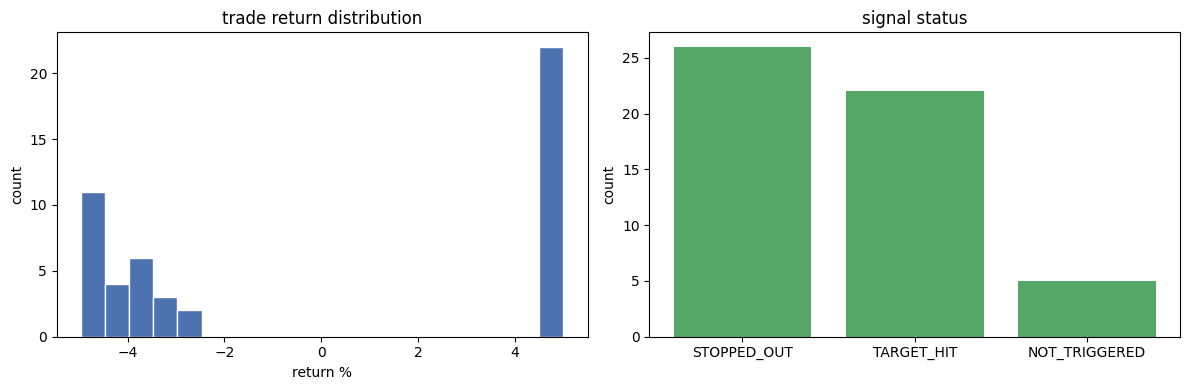

In [9]:
if not result_df.empty:
    triggered = result_df[result_df["status"].isin(["STOPPED_OUT", "TARGET_HIT", "OPEN"])].copy()
    if not triggered.empty:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].hist(triggered["return_pct"].dropna(), bins=20, color="#4C72B0", edgecolor="white")
        axes[0].set_title("trade return distribution")
        axes[0].set_xlabel("return %")
        axes[0].set_ylabel("count")

        status_counts = result_df["status"].value_counts()
        axes[1].bar(status_counts.index, status_counts.values, color="#55A868")
        axes[1].set_title("signal status")
        axes[1].set_ylabel("count")

        plt.tight_layout()
        plt.show()
    else:
        print("nothing triggered yet")
